# Exploratory Data Analysis

EDA on the credit card transactions dataset. Target column: `Class` (0 = legitimate, 1 = fraud).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Overview

In [2]:
DATA_PATH = Path('..') / 'data' / 'cleaned.csv'
df = pd.read_csv(DATA_PATH)

TARGET = 'Class'
TASK = 'classification' if df[TARGET].nunique() <= 20 else 'regression'

print(f'Shape: {df.shape}')
print(f'Task type: {TASK}')
print(f'\nColumns ({len(df.columns)}):')
print(list(df.columns))
print('\nDtypes:')
print(df.dtypes)
df.head()

Shape: (283726, 31)
Task type: classification

Columns (31):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Target Analysis

C:\Users\Victus\AppData\Local\Temp\ipykernel_5608\1116766603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette='viridis')


Class
0    283253
1       473
Name: count, dtype: int64

Imbalance ratio (majority:minority) = 598.8 : 1


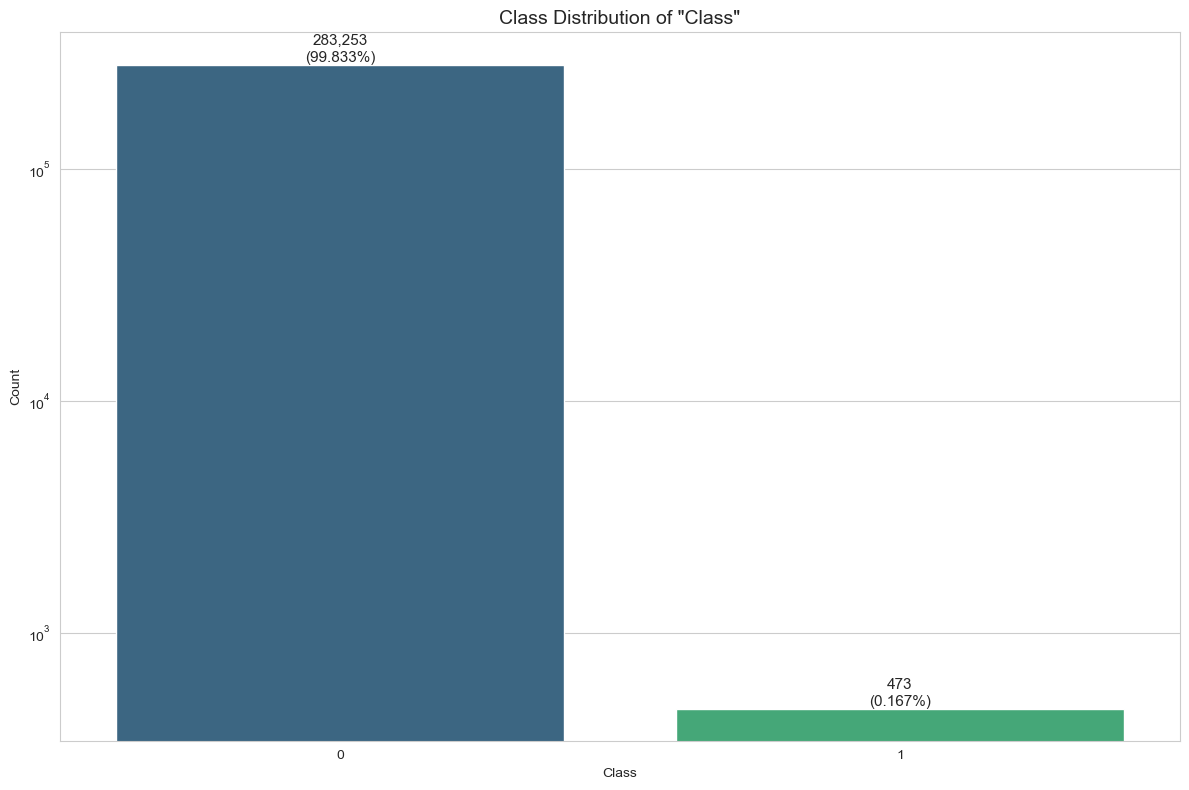

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

if TASK == 'classification':
    counts = df[TARGET].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette='viridis')
    for i, v in enumerate(counts.values):
        pct = v / counts.sum() * 100
        ax.text(i, v, f'{v:,}\n({pct:.3f}%)', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'Class Distribution of "{TARGET}"', fontsize=14)
    ax.set_xlabel(TARGET)
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    print(counts)
    print(f'\nImbalance ratio (majority:minority) = {counts.max() / counts.min():.1f} : 1')
else:
    sns.histplot(df[TARGET], bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of Target "{TARGET}"', fontsize=14)
    ax.set_xlabel(TARGET)
    ax.set_ylabel('Frequency')
    print(df[TARGET].describe())

plt.tight_layout()
plt.show()

## 3. Missing Values

Missing values per column:
        missing_count  missing_pct
Time                0          0.0
V1                  0          0.0
V2                  0          0.0
V3                  0          0.0
V4                  0          0.0
V5                  0          0.0
V6                  0          0.0
V7                  0          0.0
V8                  0          0.0
V9                  0          0.0
V10                 0          0.0
V11                 0          0.0
V12                 0          0.0
V13                 0          0.0
V14                 0          0.0
V15                 0          0.0
V16                 0          0.0
V17                 0          0.0
V18                 0          0.0
V19                 0          0.0
V20                 0          0.0
V21                 0          0.0
V22                 0          0.0
V23                 0          0.0
V24                 0          0.0
V25                 0          0.0
V26                 0       

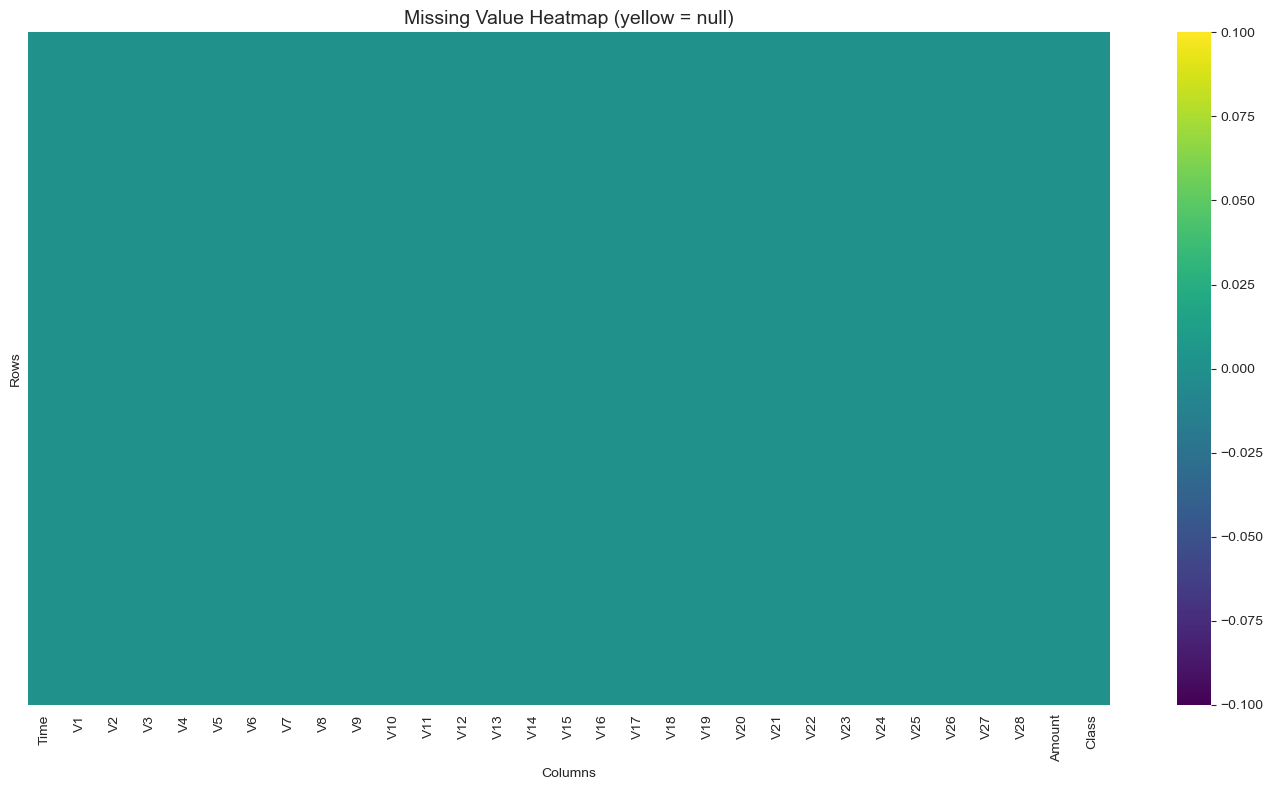

In [4]:
missing = df.isnull().sum().to_frame('missing_count')
missing['missing_pct'] = missing['missing_count'] / len(df) * 100
print('Missing values per column:')
print(missing)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (yellow = null)', fontsize=14)
ax.set_xlabel('Columns')
ax.set_ylabel('Rows')
plt.tight_layout()
plt.show()

## 4. Feature Distributions

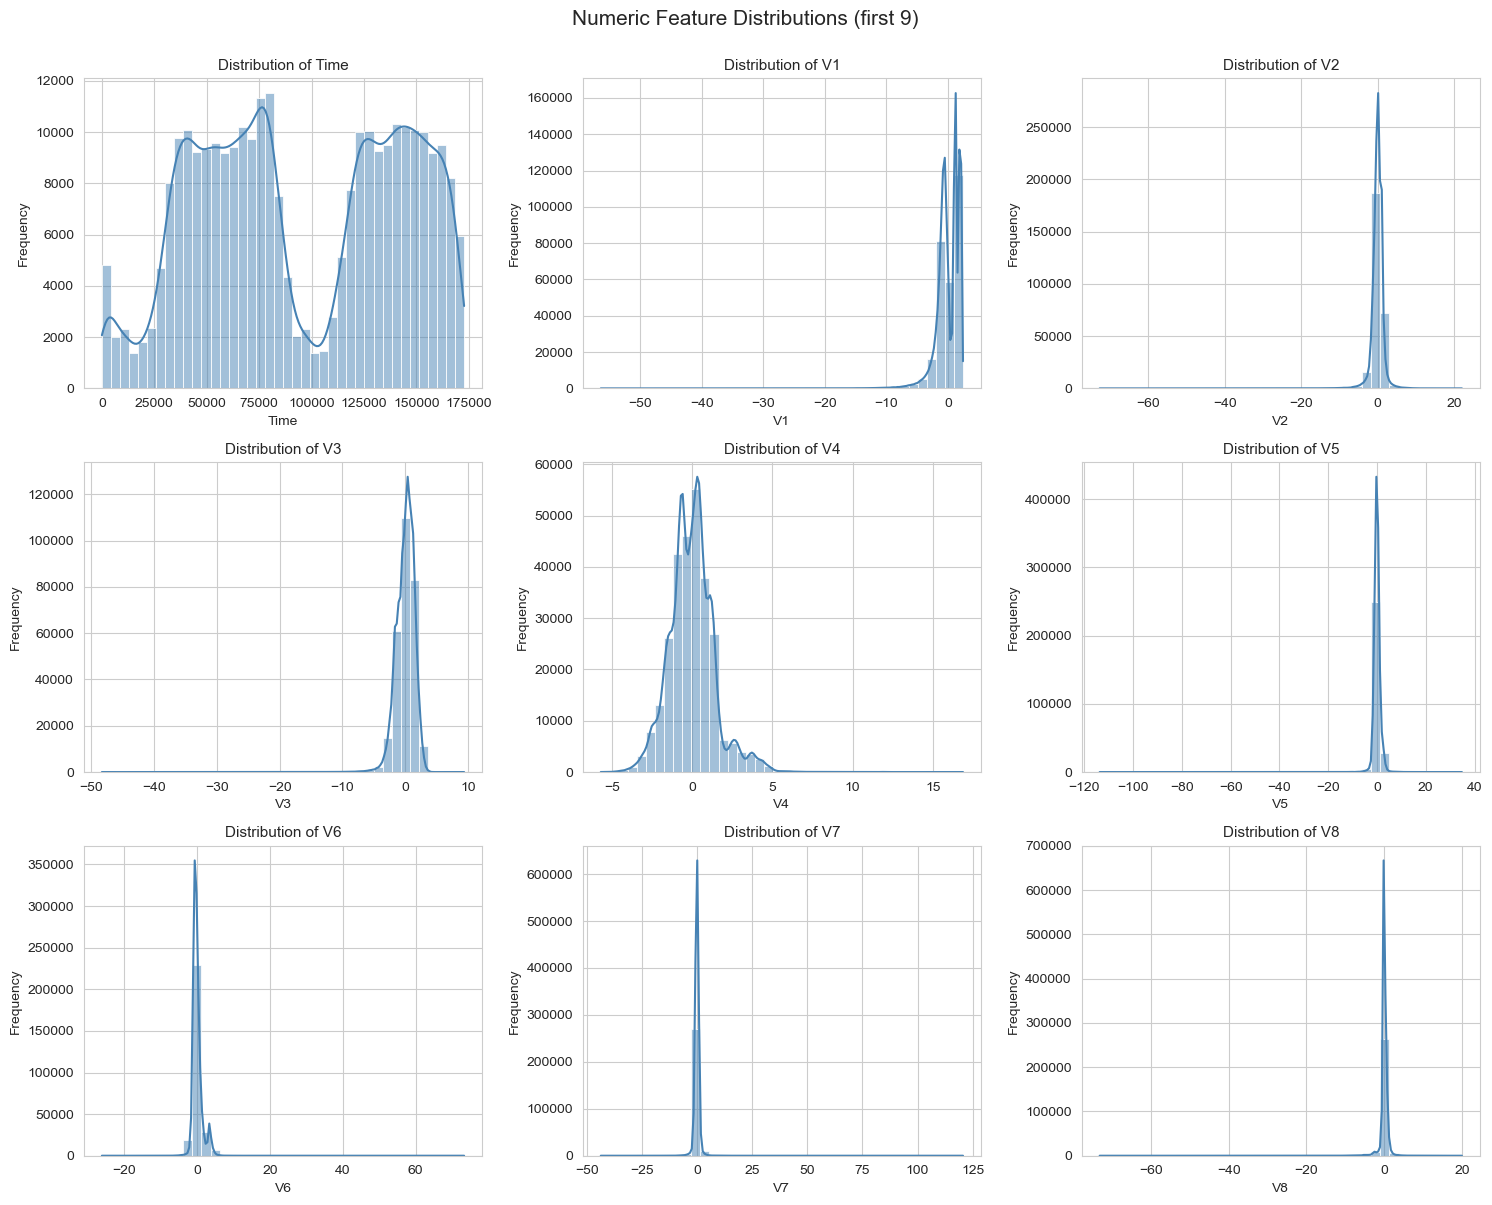

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in numeric_cols if c != TARGET]
features_to_plot = feature_cols[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, features_to_plot):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

for ax in axes.flat[len(features_to_plot):]:
    ax.set_visible(False)

fig.suptitle('Numeric Feature Distributions (first 9)', fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

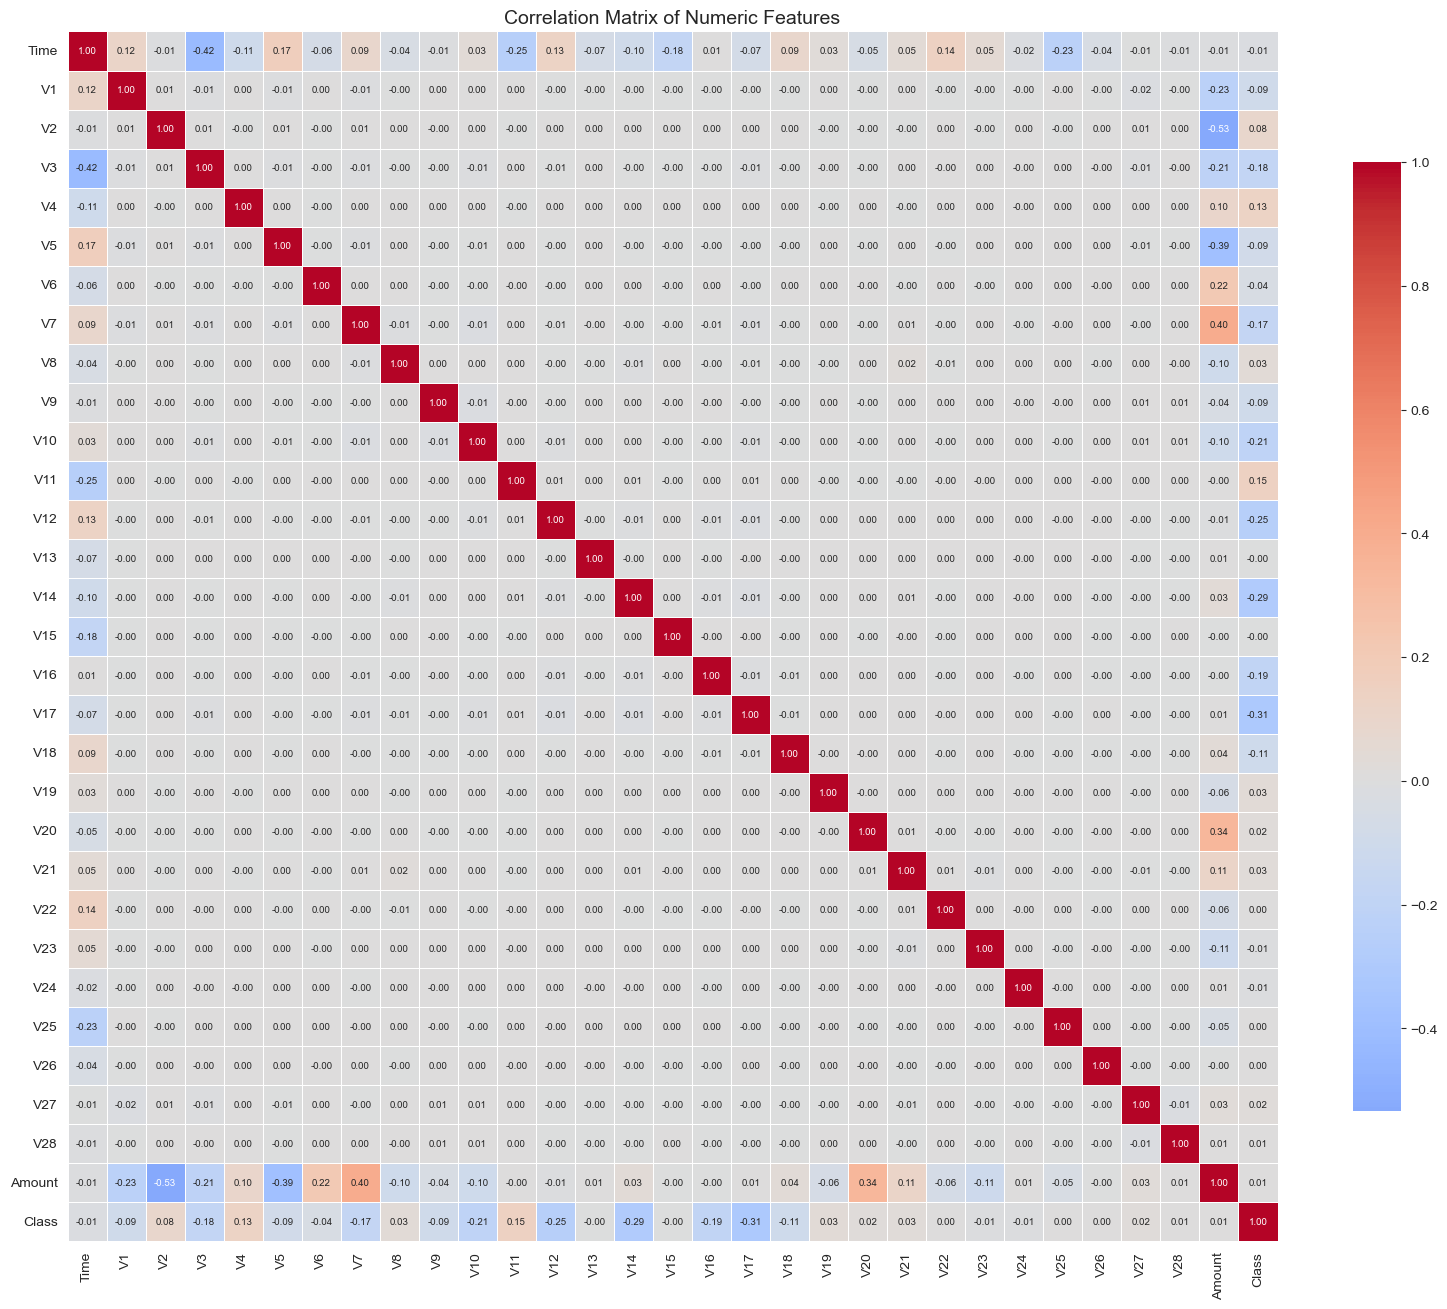

In [6]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.7},
    ax=ax,
)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Features vs Target

Top 3 features by |correlation| with target:
V17    0.313498
V14    0.293375
V12    0.250711
Name: Class, dtype: float64


C:\Users\Victus\AppData\Local\Temp\ipykernel_5608\2980766281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET], y=df[col], ax=ax, palette='Set2')
C:\Users\Victus\AppData\Local\Temp\ipykernel_5608\2980766281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET], y=df[col], ax=ax, palette='Set2')
C:\Users\Victus\AppData\Local\Temp\ipykernel_5608\2980766281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET], y=df[col], ax=ax, palette='Set2')


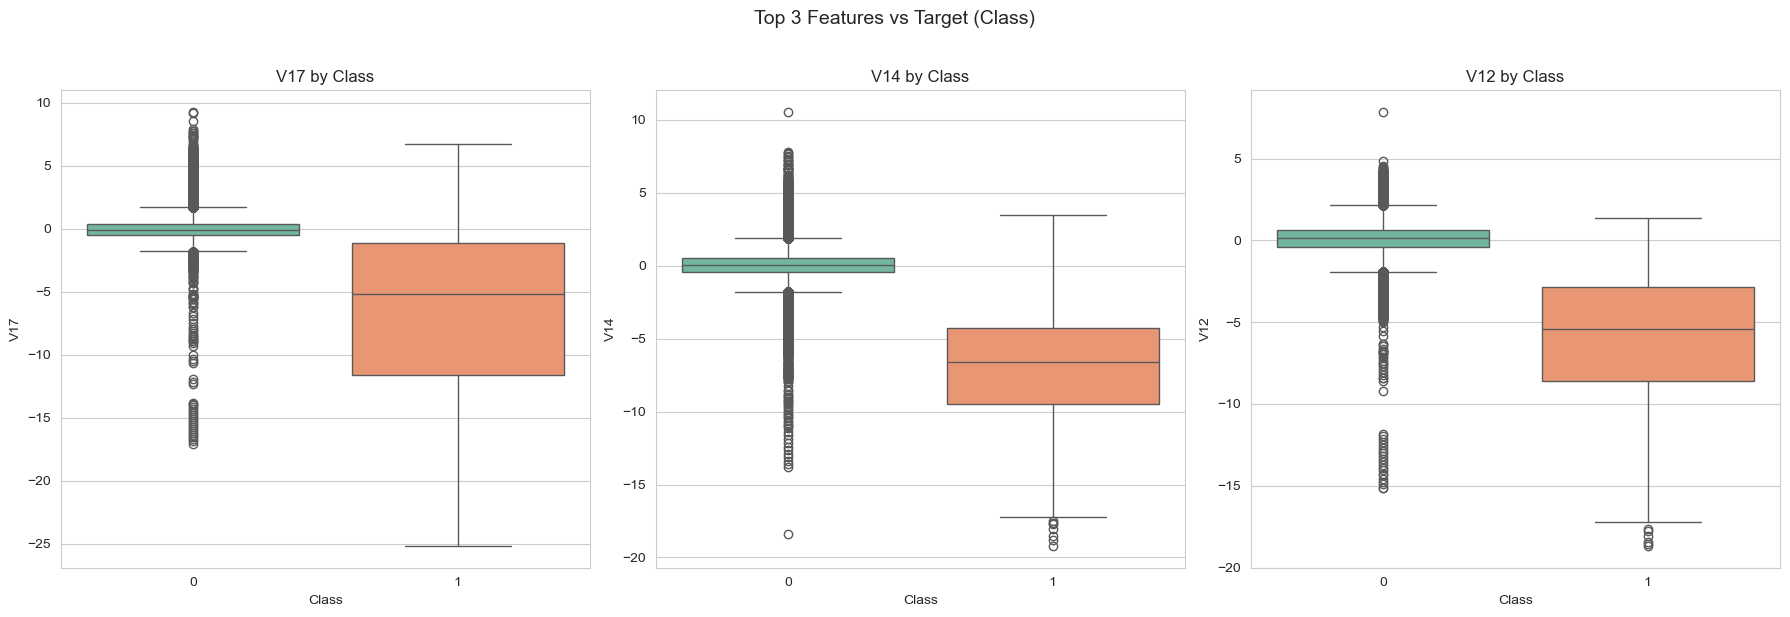

In [7]:
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top3 = target_corr.head(3).index.tolist()
print('Top 3 features by |correlation| with target:')
print(target_corr.head(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, top3):
    if TASK == 'classification':
        sns.boxplot(x=df[TARGET], y=df[col], ax=ax, palette='Set2')
        ax.set_title(f'{col} by {TARGET}', fontsize=12)
        ax.set_xlabel(TARGET)
        ax.set_ylabel(col)
    else:
        ax.scatter(df[col], df[TARGET], alpha=0.4, s=10, color='steelblue')
        ax.set_title(f'{col} vs {TARGET}', fontsize=12)
        ax.set_xlabel(col)
        ax.set_ylabel(TARGET)

fig.suptitle(f'Top 3 Features vs Target ({TARGET})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Key Findings

- **Severe class imbalance**: fraud cases are a tiny minority of the dataset, so accuracy alone is misleading — evaluation should rely on precision/recall, ROC-AUC, or PR-AUC.
- **PCA-style features (`V1`–`V28`)** are roughly zero-centered and bell-shaped, but several have heavy tails that may benefit from robust scaling or clipping.
- **`Amount`** is highly skewed with a long right tail; a `log1p` transform is likely worth trying before linear models.
- **Inter-feature correlation is low** between the `V*` columns (they are PCA components by construction); the strongest correlations are between a handful of `V*` features and the target, making them the most discriminative signals.
- **No missing values** were detected, so imputation is not required and the pipeline can focus on scaling, resampling, and model selection.